RunnablePassthrough
- Purpose: A special primitive that passes its input through as
output without any changes. It doesn't modify the data.
- When to Use: It's extremely useful in data pipelines, especially with
RunnableParallel , when you want to:
1. Keep the original input for later steps.
2. Pass data to a parallel branch while also using it in another
branch

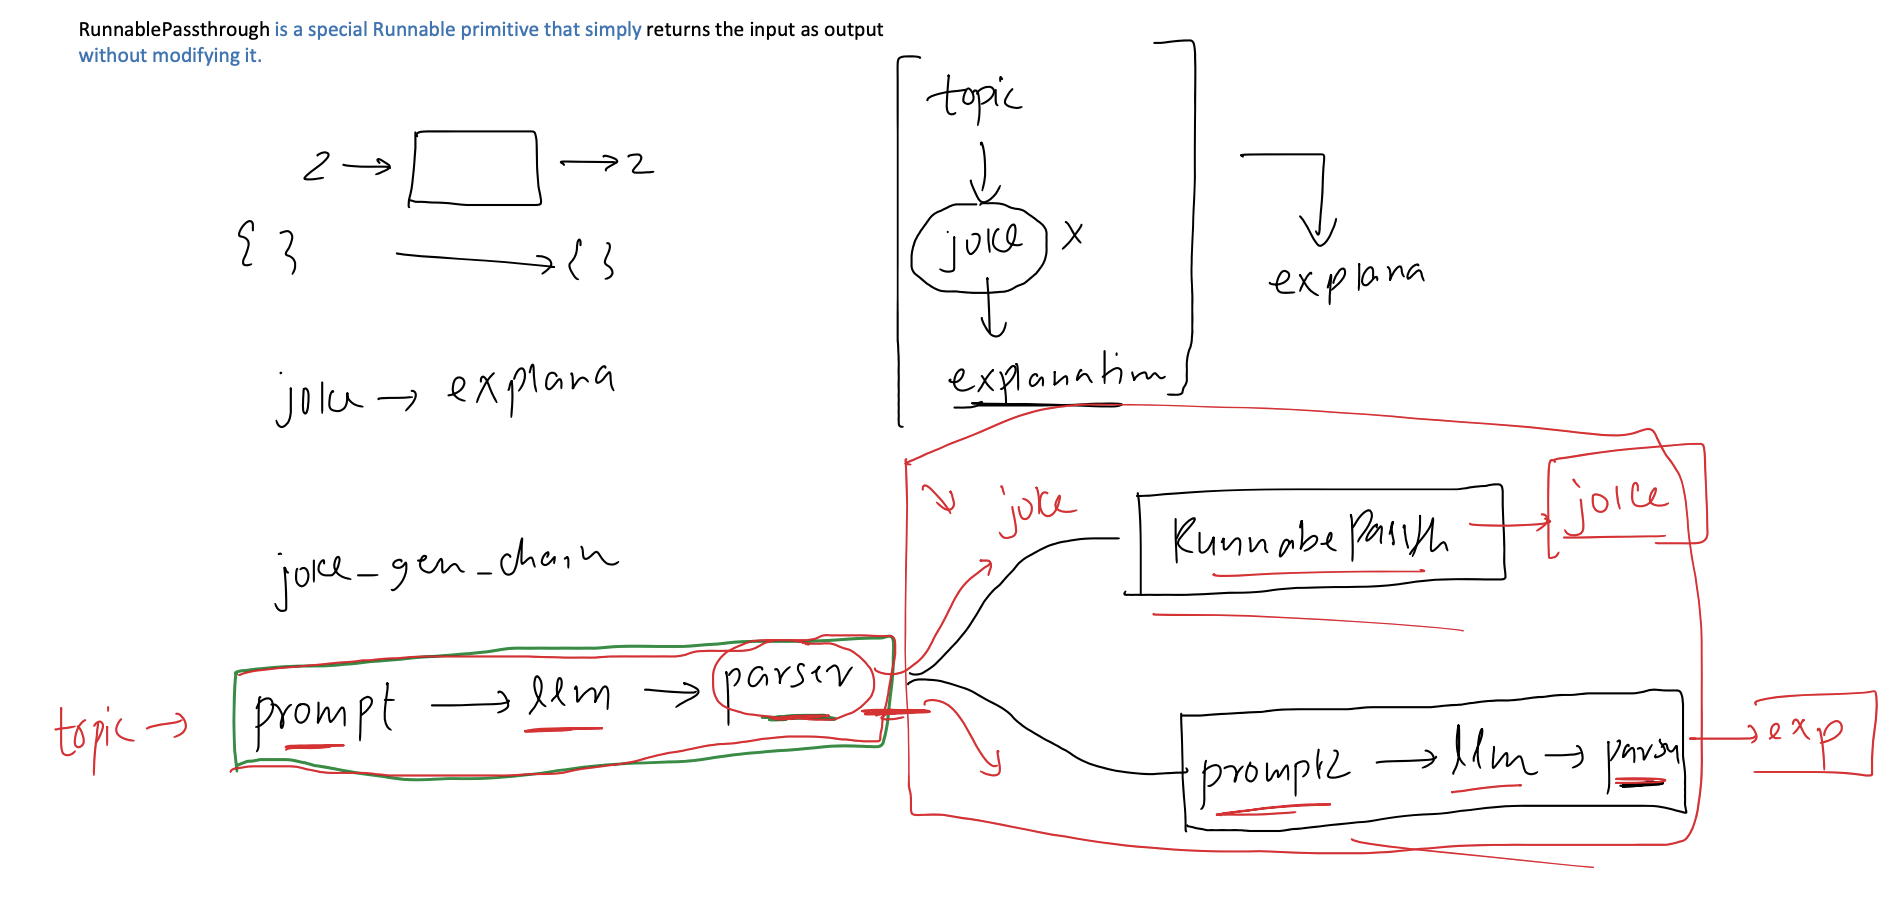

Code Example (Scenario: Generate joke and then explain it,
returning both):

### initialize model and parser

In [1]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
import os

# Load environment variables
load_dotenv()

api_key = os.getenv("Hugging_face_api_token")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    # repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation",
    huggingfacehub_api_token=api_key,
)

# Wrap with chat interface
# multiple models because we are using parallel chain in one point
model = ChatHuggingFace(llm=llm)

In [2]:
from langchain_core.output_parsers import StrOutputParser
parser=StrOutputParser()

### create prompt templates

In [3]:
from langchain_core.prompts import PromptTemplate
# generate joke template
joke_gen_template=PromptTemplate(
    template="Tell a joke about {topic}",
    input_variables=["topic"]
)
#explain joke template
joke_exp_template=PromptTemplate(
    template="Explain the joke : {joke}",
    input_variables=["joke"]
)

### create chains and invoke

In [4]:
from langchain_core.runnables import RunnableParallel,RunnablePassthrough
# first chain,sequential chain
joke_gen_chain=joke_gen_template|model|parser

#parallel_chain

parallel_chain=RunnableParallel(
    {
        "joke":RunnablePassthrough(), # passes the joke untouched from joke_gen_chain
        "explaination":joke_exp_template|model|parser
    }
)

# Final Chain:Generate ->(passthrough joke and explaination)
final_chain=joke_gen_chain|parallel_chain


In [6]:
result=final_chain.invoke({
    "topic":"coding"
})

In [7]:
print(result)
print(type(result)) #parallel chain gives output dict,with those invoke parts as keys
print(result.keys())

{'joke': "Why don't programmers like nature? It has too many bugs.\n\nBut on a serious note, programming can be a lot like gardening - it requires patience, careful planning, and a lot of weeding out of errors!", 'explaination': 'The joke "Why don\'t programmers like nature? It has too many bugs" is a play on words that uses the double meaning of the term "bugs." In programming, a bug refers to an error or flaw in the code that causes it to behave unexpectedly or incorrectly. In nature, a bug is an insect or other small invertebrate. The humor comes from the unexpected connection between these two different meanings.\n\nHowever, as you point out, programming and gardening do share some similarities. Both require attention to detail, careful planning, and persistence in dealing with unexpected issues. In programming, this might mean debugging code to find and fix errors. In gardening, it might mean identifying and removing weeds or pests that threaten to harm the plants. Despite their d

In [8]:
result["joke"]

"Why don't programmers like nature? It has too many bugs.\n\nBut on a serious note, programming can be a lot like gardening - it requires patience, careful planning, and a lot of weeding out of errors!"

In [9]:
result["explaination"]

'The joke "Why don\'t programmers like nature? It has too many bugs" is a play on words that uses the double meaning of the term "bugs." In programming, a bug refers to an error or flaw in the code that causes it to behave unexpectedly or incorrectly. In nature, a bug is an insect or other small invertebrate. The humor comes from the unexpected connection between these two different meanings.\n\nHowever, as you point out, programming and gardening do share some similarities. Both require attention to detail, careful planning, and persistence in dealing with unexpected issues. In programming, this might mean debugging code to find and fix errors. In gardening, it might mean identifying and removing weeds or pests that threaten to harm the plants. Despite their differences, both programming and gardening can be seen as creative and rewarding pursuits that require a good deal of problem-solving skills.'